In [347]:
# importing libraries
%matplotlib inline
!pip install plotly-express

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import math

from scipy import stats
from scipy.signal import find_peaks
import warnings
warnings.filterwarnings('ignore')

In [348]:

# reading raw data file
columns = ['timestamp', 'accX', 'accY', 'accZ', 'gyroX', 'gyroY', 'gyroZ']
dfs = list()

for file in os.listdir('./tcp_server/out_converted/15_05_test'):
    har_df = pd.read_csv('./tcp_server/out_converted/15_05_test/'+ file, header = 0, names = columns, on_bad_lines='skip')
    har_df['activity'] = file.split('.')[0]
    har_df['index'] = int(file.split('.')[1])
    dfs.append(har_df)

df = pd.concat(dfs, ignore_index=True)

# # removing null values
# har_df = har_df.dropna()
# har_df.shape

# # transforming the z-axis to float
# har_df['z-axis'] = har_df['z-axis'].str.replace(';', '')
# har_df['z-axis'] = har_df['z-axis'].apply(lambda x:float(x))

# # drop the rows where timestamp is 0
# df = har_df[har_df['timestamp'] != 0]

# now arrange data in ascending order of the user and timestamp
# df = df.sort_values(by = ['user', 'timestamp'], ignore_index=True)

In [349]:
print(df)

        timestamp  accX  accY   accZ  gyroX  gyroY  gyroZ  activity  index
0               8 -0.88  0.50  10.23   0.09  -0.02  -0.13     Break      1
1              26 -1.68  0.08   7.28  -0.21   0.04  -0.18     Break      1
2              46  0.04  0.08   7.97  -0.17  -0.08  -0.17     Break      1
3              67  2.57  0.15  12.41  -0.11   0.07  -0.12     Break      1
4              87 -0.84  0.23   8.20  -0.11   0.04  -0.11     Break      1
...           ...   ...   ...    ...    ...    ...    ...       ...    ...
112277       4922 -2.34 -1.84   8.16   0.03   0.01  -0.20  Straight     92
112278       4841 -1.57 -0.54  10.57  -0.09   0.14  -0.19  Straight     92
112279       4861 -2.61 -0.96   8.54  -0.05   0.02  -0.19  Straight     92
112280       4881  0.23 -0.92   9.08  -0.06  -0.02  -0.25  Straight     92
112281       4902 -2.76 -1.53   8.58  -0.02   0.13  -0.22  Straight     92

[112282 rows x 9 columns]


In [350]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(-2**15,2**15-1))

scaler.fit(df.to_numpy()[:, [1,2,3,4,5,6]])

print(scaler.data_max_)
print(scaler.data_min_)

scaler.fit([[50,50,50,5,5,5],[-50,-50,-50,-5,-5,-5]])

print(scaler.data_max_)
print(scaler.data_min_)

print((df.to_numpy()[0:5, [1,2,3,4,5,6]]))

print(scaler.transform(df.to_numpy()[0:5, [1,2,3,4,5,6]]).astype(np.int16))

X_std = (0.5 - -50) / (100)
print(X_std)
X_scaled = X_std * (2**15-1 - -2**15) + -2**15
print(np.int16(X_scaled))

X_std = (0.08 - -50) / (100)
print(X_std)
X_scaled = X_std * (2**15-1 - -2**15) + -2**15
print(np.int16(X_scaled))


[36.7  13.64 44.09  1.52  2.88  2.19]
[-47.69 -21.88 -23.55  -1.14  -2.77  -3.02]
[50. 50. 50.  5.  5.  5.]
[-50. -50. -50.  -5.  -5.  -5.]
[[-0.88 0.5 10.23 0.09 -0.02 -0.13]
 [-1.68 0.08 7.28 -0.21 0.04 -0.18]
 [0.04 0.08 7.97 -0.17 -0.08 -0.17]
 [2.57 0.15 12.41 -0.11 0.07 -0.12]
 [-0.84 0.23 8.2 -0.11 0.04 -0.11]]
[[ -577   327  6703   589  -131  -852]
 [-1101    51  4770 -1376   261 -1180]
 [   25    51  5222 -1114  -524 -1114]
 [ 1683    97  8132  -721   458  -786]
 [ -550   150  5373  -721   261  -721]]
0.505
327
0.5008
51


In [351]:
print(df)
df[['accX', 'accY', 'accZ', 'gyroX', 'gyroY', 'gyroZ']] = scaler.fit_transform(df[['accX', 'accY', 'accZ', 'gyroX', 'gyroY', 'gyroZ']]).astype(np.int16)

print(df)

        timestamp  accX  accY   accZ  gyroX  gyroY  gyroZ  activity  index
0               8 -0.88  0.50  10.23   0.09  -0.02  -0.13     Break      1
1              26 -1.68  0.08   7.28  -0.21   0.04  -0.18     Break      1
2              46  0.04  0.08   7.97  -0.17  -0.08  -0.17     Break      1
3              67  2.57  0.15  12.41  -0.11   0.07  -0.12     Break      1
4              87 -0.84  0.23   8.20  -0.11   0.04  -0.11     Break      1
...           ...   ...   ...    ...    ...    ...    ...       ...    ...
112277       4922 -2.34 -1.84   8.16   0.03   0.01  -0.20  Straight     92
112278       4841 -1.57 -0.54  10.57  -0.09   0.14  -0.19  Straight     92
112279       4861 -2.61 -0.96   8.54  -0.05   0.02  -0.19  Straight     92
112280       4881  0.23 -0.92   9.08  -0.06  -0.02  -0.25  Straight     92
112281       4902 -2.76 -1.53   8.58  -0.02   0.13  -0.22  Straight     92

[112282 rows x 9 columns]
        timestamp  accX  accY  accZ  gyroX  gyroY  gyroZ  activity  index

In [352]:
max = df[df['activity'] == 'Break'].max(axis='index')['index']
print(max)	

104


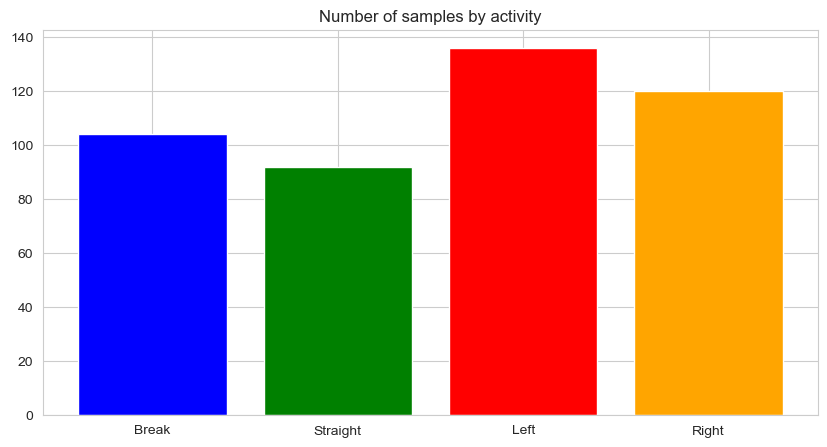

In [353]:
sns.set_style("whitegrid")
plt.figure(figsize = (10, 5))
max_break = df[df['activity'] == 'Break'].max(axis='index')['index']
max_straight = df[df['activity'] == 'Straight'].max(axis='index')['index']
max_left = df[df['activity'] == 'Left'].max(axis='index')['index']
max_right = df[df['activity'] == 'Right'].max(axis='index')['index']
plt.bar(['Break', 'Straight', 'Left', 'Right'], [max_break, max_straight, max_left, max_right], color = ['blue', 'green', 'red', 'orange'])
plt.title('Number of samples by activity')
plt.show()

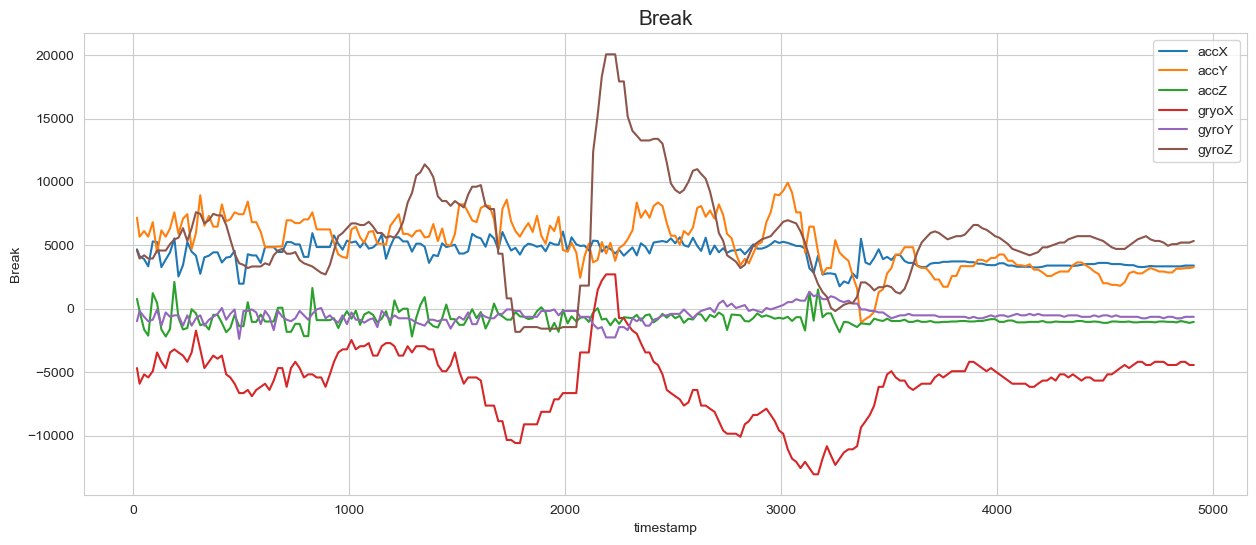

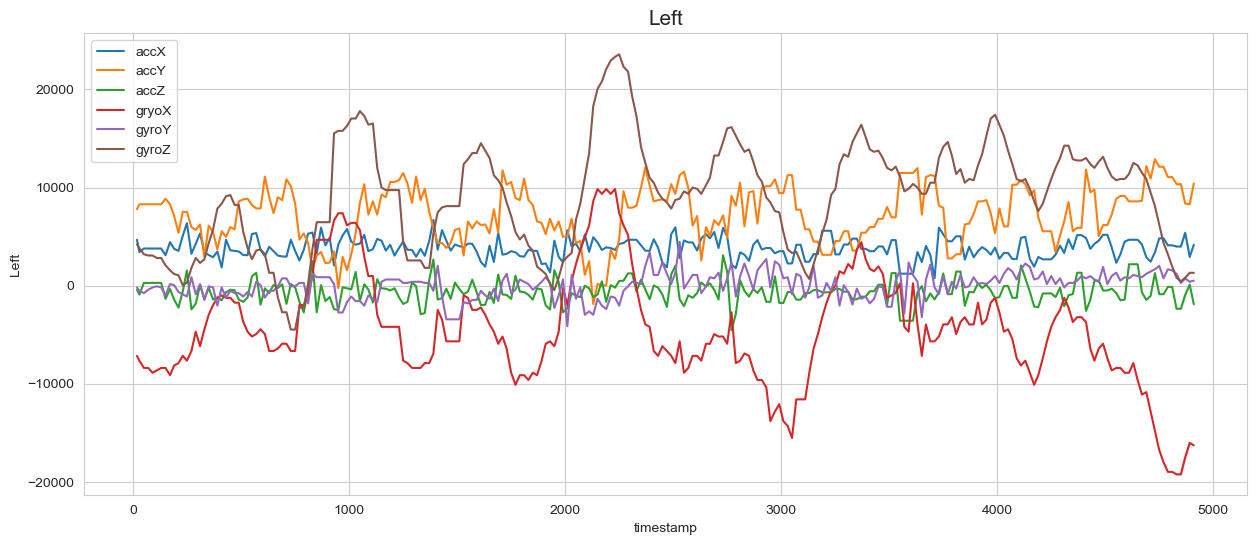

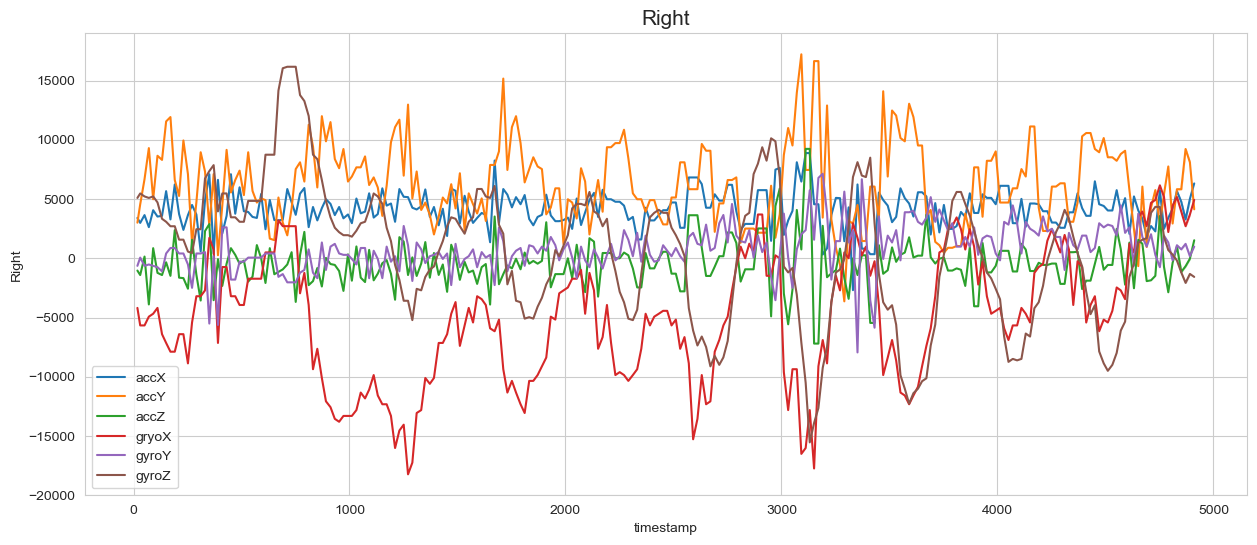

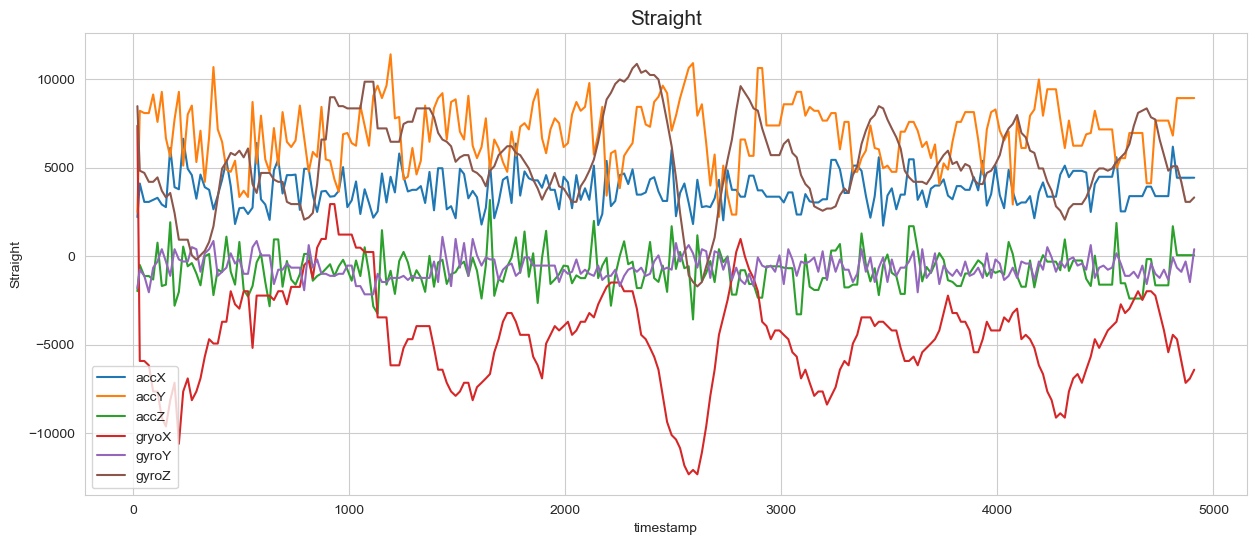

In [354]:
for i in ['Break', 'Left', 'Right', 'Straight']:
  data_36 = df[(df['index'] == 10) & (df['activity'] == i)][:400]
  plt.figure(figsize = (15, 6))
  sns.lineplot(y = 'accX', x = 'timestamp', data = data_36, label= 'accX')
  sns.lineplot(y = 'accY', x = 'timestamp', data = data_36, label= 'accY')
  sns.lineplot(y = 'accZ', x = 'timestamp', data = data_36, label= 'accZ')
  sns.lineplot(y = 'gyroX', x = 'timestamp', data = data_36, label= 'gryoX')
  sns.lineplot(y = 'gyroY', x = 'timestamp', data = data_36, label= 'gyroY')
  sns.lineplot(y = 'gyroZ', x = 'timestamp', data = data_36, label= 'gyroZ')
  plt.ylabel(i)
  plt.title(i, fontsize = 15)
  plt.show()

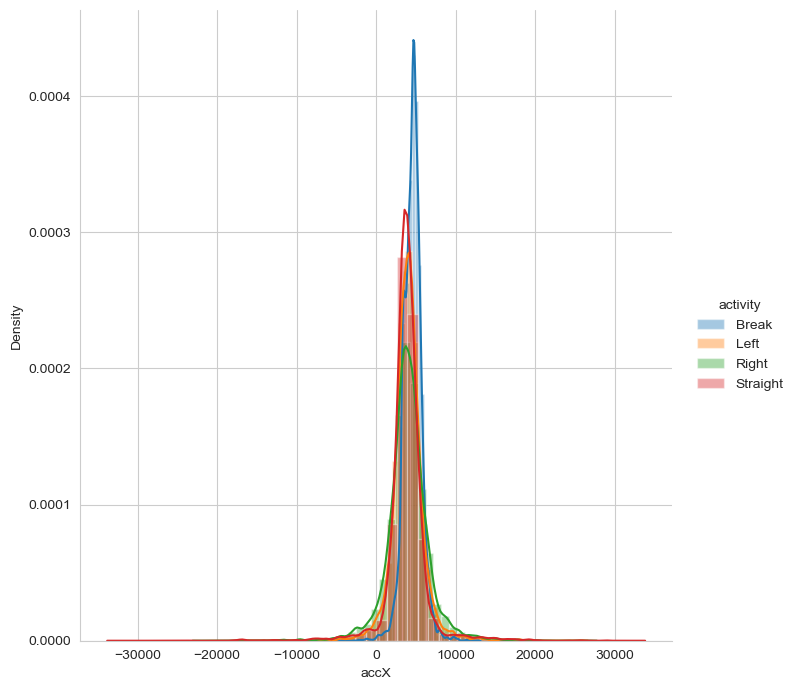

In [355]:
g = sns.FacetGrid(df, hue = 'activity', height=7).map(sns.distplot, 'accX').add_legend()
g.map(sns.scatterplot)

plt.show()

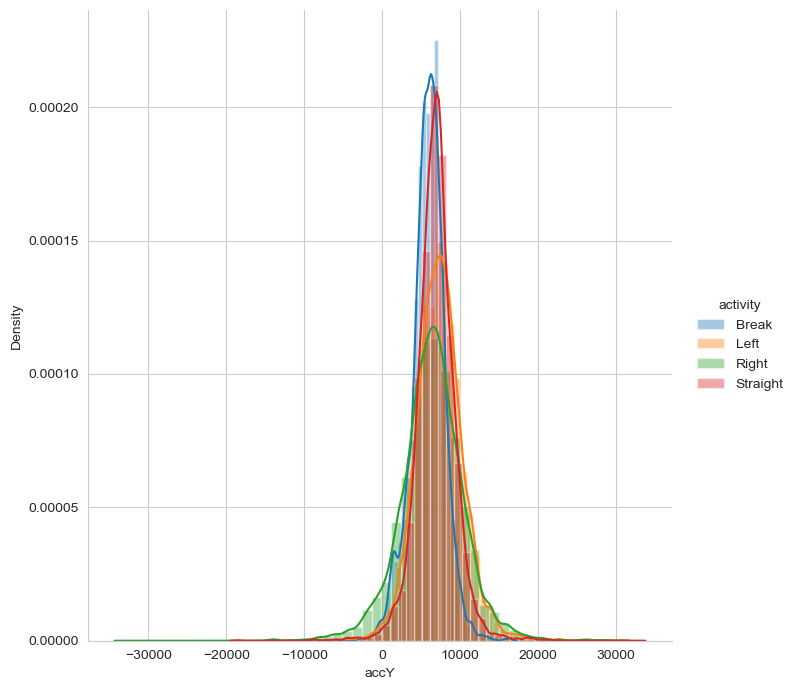

In [356]:
g = sns.FacetGrid(df, hue = 'activity', height=7).map(sns.distplot, 'accY').add_legend()
g.map(sns.scatterplot)
plt.show()

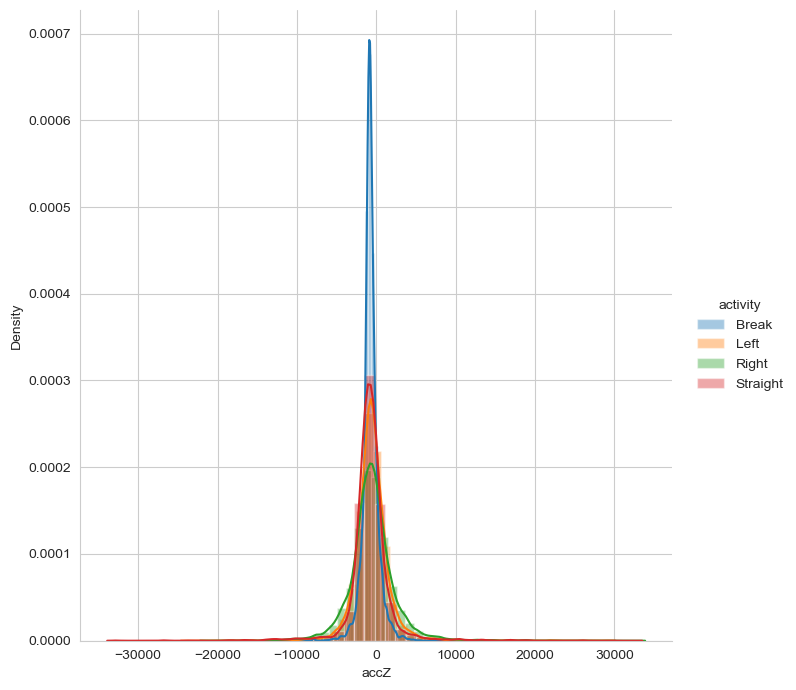

In [357]:
g = sns.FacetGrid(df, hue = 'activity', height=7).map(sns.distplot, 'accZ').add_legend()
g.map(sns.scatterplot)
plt.show()

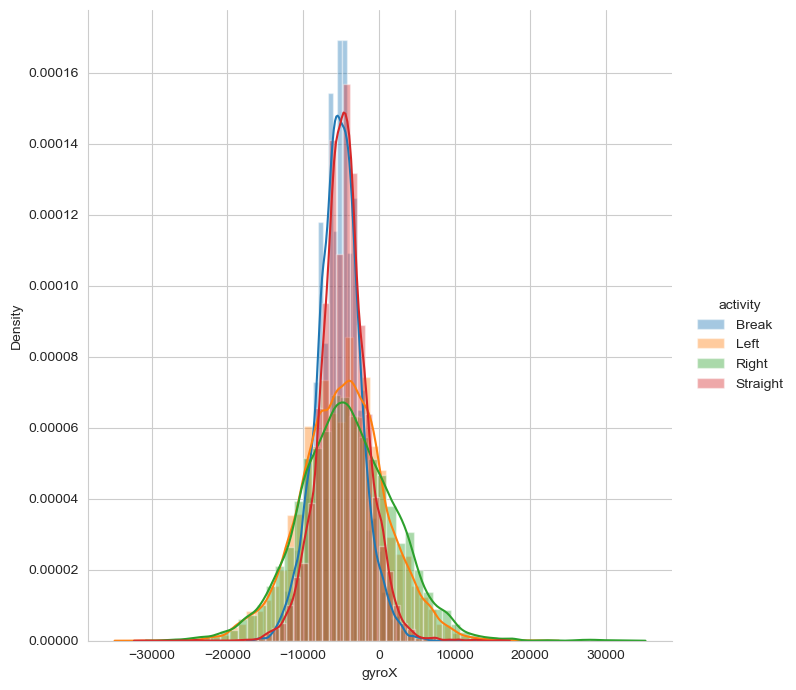

In [358]:
g = sns.FacetGrid(df, hue = 'activity', height=7).map(sns.distplot, 'gyroX').add_legend()
g.map(sns.scatterplot)
plt.show()

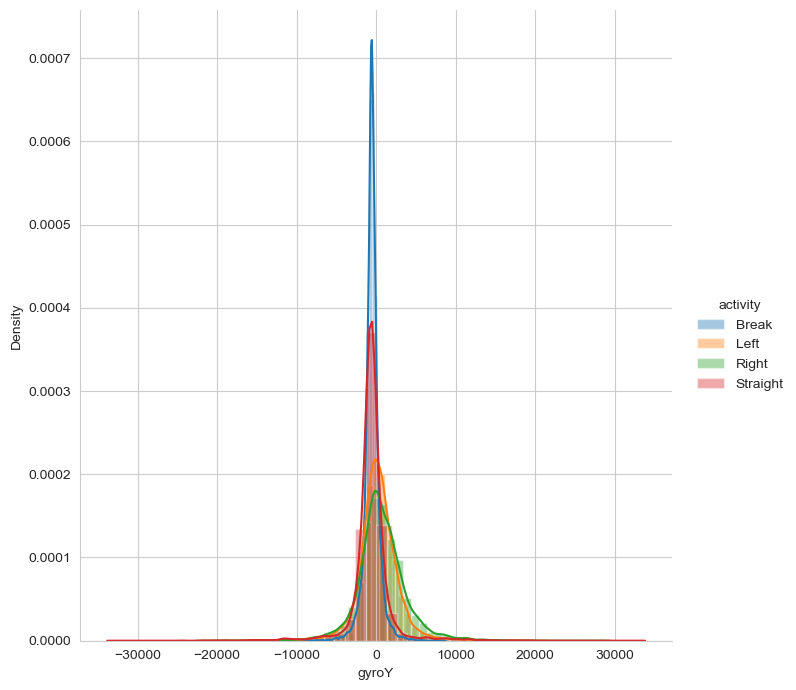

In [359]:
g = sns.FacetGrid(df, hue = 'activity', height=7).map(sns.distplot, 'gyroY').add_legend()
g.map(sns.scatterplot)
plt.show()

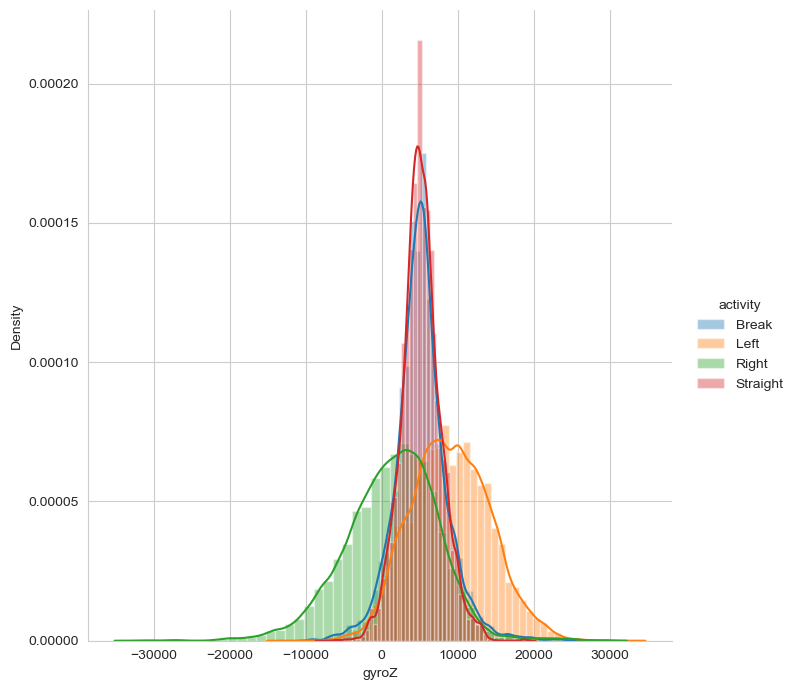

In [360]:
g = sns.FacetGrid(df, hue = 'activity', height=7).map(sns.distplot, 'gyroZ').add_legend()
g.map(sns.scatterplot)
plt.show()

In [361]:
# train data -> Users upto User ID = 27 (i.e. 27 users)


mask_train_break = (df['index'] <= (math.floor(max_break * 0.8))) & (df['activity'] == 'Break')
mask_train_straight = (df['index'] <= (math.floor(max_straight * 0.8))) & (df['activity'] == 'Straight')
mask_train_left = (df['index'] <= (math.floor(max_left * 0.8))) & (df['activity'] == 'Left')
mask_train_right = (df['index'] <= (math.floor(max_right * 0.8))) & (df['activity'] == 'Right')

df_train = pd.concat([df[mask_train_break], df[mask_train_straight], df[mask_train_left], df[mask_train_right]])

# test data -> Users from User ID = 28 to 36 (i.e. 9 users)
mask_test_break = (df['index'] > (math.floor(max_break * 0.8))) & (df['activity'] == 'Break')
mask_test_straight = (df['index'] > (math.floor(max_straight * 0.8))) & (df['activity'] == 'Straight')
mask_test_left = (df['index'] > (math.floor(max_left * 0.8))) & (df['activity'] == 'Left')
mask_test_right = (df['index'] > (math.floor(max_right * 0.8))) & (df['activity'] == 'Right')


df_test = pd.concat([df[mask_test_break], df[mask_test_straight], df[mask_test_left], df[mask_test_right]])

print(df_test)

       timestamp  accX   accY  accZ  gyroX  gyroY  gyroZ activity  index
20744         22  3824   1032   590  -4435  -4002   6477    Break     84
20745         41  3971   1586  -562   3448   -174  10125    Break     84
20746         61  3459   4851 -2267   1970   -406   9119    Break     84
20747         81  3459   4851 -2267   1724    -58  10125    Break     84
20748        102  3257   7176 -3304   1231  -1566  10880    Break     84
...          ...   ...    ...   ...    ...    ...    ...      ...    ...
89280       4922 -4803  11272 -7838  -4188   1333   2452    Right    120
89281       4842  5400   5682  4369  -7638   1913   -566    Right    120
89282       4861  2721   7803 -1851  -3942   2377   2578    Right    120
89283       4882  2659   5202 -1599  -6159    869   1068    Right    120
89284       4902  3404   8302 -1492  -4927  -1334   3458    Right    120

[22993 rows x 9 columns]


In [362]:
xa_list = []
xg_list = []
ya_list = []
yg_list = []
za_list = []
zg_list = []
train_labels = []

window_size = 100
step_size = 50

# creating overlaping windows of size window-size 120
for i in range(0, df_train.shape[0] - window_size, step_size):
    xs_acc = df_train['accX'].values[i: i + window_size]
    ys_acc = df_train['accY'].values[i: i + window_size]
    zs_acc = df_train['accZ'].values[i: i + window_size]
    xs_gyro = df_train['gyroX'].values[i: i + window_size]
    ys_gyro = df_train['gyroY'].values[i: i + window_size]
    zs_gyro = df_train['gyroZ'].values[i: i + window_size]
    
    label = df_train['activity'][i: i + window_size].mode()[0]

    xa_list.append(xs_acc)
    xg_list.append(xs_gyro)
    ya_list.append(ys_acc)
    yg_list.append(ys_gyro)
    za_list.append(zs_acc)
    zg_list.append(zs_gyro)
    train_labels.append(label)

# Statistical Features on raw x, y and z in time domain
X_train = pd.DataFrame()

# mean
X_train['xa_mean'] = pd.Series(xa_list).apply(lambda x: x.mean())
X_train['ya_mean'] = pd.Series(ya_list).apply(lambda x: x.mean())
X_train['zg_mean'] = pd.Series(zg_list).apply(lambda x: x.mean())

# max
X_train['xg_max'] = pd.Series(xg_list).apply(lambda x: x.max())

# interquartile range
X_train['za_IQR'] = pd.Series(za_list).apply(lambda x: np.percentile(x, 75) - np.percentile(x, 25))

# signal magnitude area
X_train['sma_gyro'] =    pd.Series(xg_list).apply(lambda x: np.sum(abs(x)/100)) + pd.Series(yg_list).apply(lambda x: np.sum(abs(x)/100)) \
                  + pd.Series(zg_list).apply(lambda x: np.sum(abs(x)/100))

In [363]:
xa_list = []
xg_list = []
ya_list = []
yg_list = []
za_list = []
zg_list = []
test_labels = []

# creating overlaping windows of size window-size 100
for i in range(0, df_test.shape[0] - window_size, step_size):
    xs_acc = df_test['accX'].values[i: i + window_size]
    ys_acc = df_test['accY'].values[i: i + window_size]
    zs_acc = df_test['accZ'].values[i: i + window_size]
    xs_gyro = df_test['gyroX'].values[i: i + window_size]
    ys_gyro = df_test['gyroY'].values[i: i + window_size]
    zs_gyro = df_test['gyroZ'].values[i: i + window_size]
    
    label = df_test['activity'][i: i + window_size].mode()[0]

    xa_list.append(xs_acc)
    xg_list.append(xs_gyro)
    ya_list.append(ys_acc)
    yg_list.append(ys_gyro)
    za_list.append(zs_acc)
    zg_list.append(zs_gyro)
    test_labels.append(label)

# Statistical Features on raw x, y and z in time domain
X_test = pd.DataFrame()

# mean
X_test['xa_mean'] = pd.Series(xa_list).apply(lambda x: x.mean())
X_test['ya_mean'] = pd.Series(ya_list).apply(lambda x: x.mean())
X_test['zg_mean'] = pd.Series(zg_list).apply(lambda x: x.mean())

# max
X_test['xg_max'] = pd.Series(xg_list).apply(lambda x: x.max())

# interquartile range
X_test['za_IQR'] = pd.Series(za_list).apply(lambda x: np.percentile(x, 75) - np.percentile(x, 25))

# signal magnitude area
X_test['sma_gyro'] =    pd.Series(xg_list).apply(lambda x: np.sum(abs(x)/100)) + pd.Series(yg_list).apply(lambda x: np.sum(abs(x)/100)) \
                  + pd.Series(zg_list).apply(lambda x: np.sum(abs(x)/100))


In [364]:
y_train = np.array(train_labels)
y_test = np.array(test_labels)

In [365]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

# logistic regression model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\n -------------Classification Report-------------\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8908296943231441

 -------------Classification Report-------------

              precision    recall  f1-score   support

       Break       0.97      0.82      0.89       104
        Left       0.89      0.96      0.92       140
       Right       0.95      0.89      0.92       119
    Straight       0.77      0.86      0.82        95

    accuracy                           0.89       458
   macro avg       0.89      0.88      0.89       458
weighted avg       0.90      0.89      0.89       458



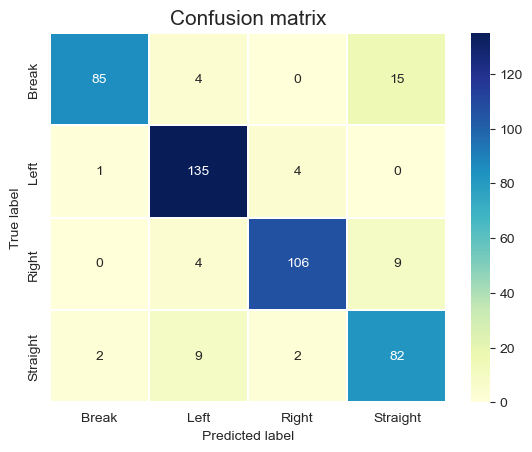

In [366]:
labels = ['Break', 'Left', 'Right', 'Straight']
confusion_Matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(confusion_Matrix, xticklabels=labels, yticklabels=labels, annot=True,linewidths = 0.1, fmt="d", cmap = 'YlGnBu')
plt.title("Confusion matrix", fontsize = 15)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

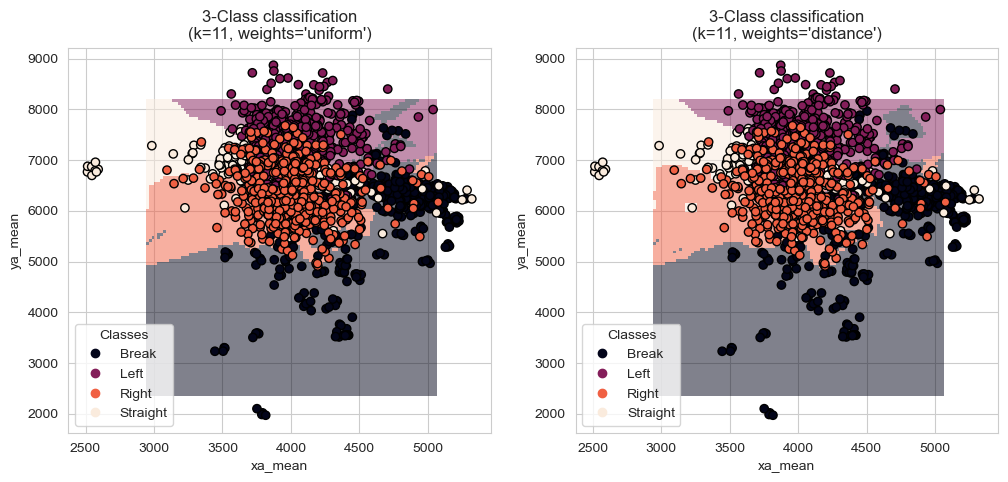

In [367]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

colors = ['Break', 'Left', 'Right', 'Straight']
n_classes = ['Break', 'Left', 'Right', 'Straight']
color = []

for i in y_train:
    color.append(colors.index(i))

clf = Pipeline(
    steps=[("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=11))]
)

from sklearn.inspection import DecisionBoundaryDisplay

X = X_train.to_numpy()[:,[0,1]]


_, axs = plt.subplots(ncols=2, figsize=(12, 5))

for ax, weights in zip(axs, ("uniform", "distance")):
    clf.set_params(knn__weights=weights).fit(X, y_train)
    disp = DecisionBoundaryDisplay.from_estimator(
        clf,
        X_test.to_numpy()[:, [0,1]],
        response_method="predict",
        plot_method="pcolormesh",
        xlabel=X_train.columns[0],
        ylabel=X_train.columns[1],
        shading="auto",
        alpha=0.5,
        ax=ax,
    )
    scatter = disp.ax_.scatter(X[:, 0], X[:, 1], c=color, edgecolors="k")
    disp.ax_.legend(
        scatter.legend_elements()[0],
        colors,
        loc="lower left",
        title="Classes",
    )
    _ = disp.ax_.set_title(
        f"3-Class classification\n(k={clf[-1].n_neighbors}, weights={weights!r})"
    )

plt.show()

In [368]:
from sklearn.ensemble import RandomForestClassifier

# Train the Random Forest model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

# Evaluate the model
accuracy_before = rf.score(X_test, y_test)
print(f'Accuracy before feature selection: {accuracy_before:.2f}')

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\n -------------Classification Report-------------\n")
print(classification_report(y_test, y_pred))

Accuracy before feature selection: 0.94
Accuracy: 0.9388646288209607

 -------------Classification Report-------------

              precision    recall  f1-score   support

       Break       0.99      0.95      0.97       104
        Left       0.94      0.96      0.95       140
       Right       0.92      0.91      0.92       119
    Straight       0.91      0.93      0.92        95

    accuracy                           0.94       458
   macro avg       0.94      0.94      0.94       458
weighted avg       0.94      0.94      0.94       458



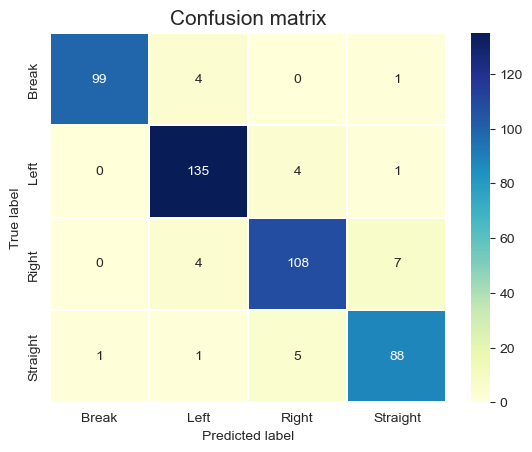

In [369]:
labels = ['Break', 'Left', 'Right', 'Straight']
confusion_Matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(confusion_Matrix, xticklabels=labels, yticklabels=labels, annot=True,linewidths = 0.1, fmt="d", cmap = 'YlGnBu')
plt.title("Confusion matrix", fontsize = 15)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

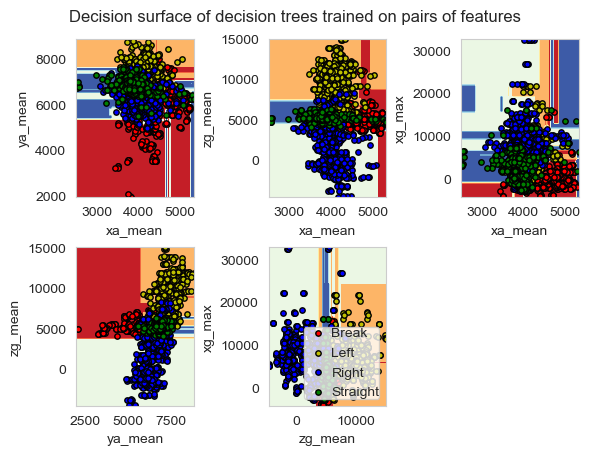

In [370]:
from sklearn.inspection import DecisionBoundaryDisplay

# Parameters
n_classes = ['Break', 'Left', 'Right', 'Straight']
plot_colors = "rybg"
plot_step = 0.02


for pairidx, pair in enumerate([[0, 1], [0, 2], [0, 3], [1, 2], [2, 3]]):
    # We only take the two corresponding features
    X = X_train.to_numpy()[:,pair]
    y = y_train

    # Train
    clf = RandomForestClassifier(n_estimators=10, max_depth=10, max_features=2, random_state=1).fit(X, y)

    # Plot the decision boundary
    ax = plt.subplot(2, 3, pairidx + 1)
    plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)
    DecisionBoundaryDisplay.from_estimator(
        clf,
        X,
        cmap=plt.cm.RdYlBu,
        response_method="predict",
        ax=ax,
        xlabel=X_train.columns[pair[0]],
        ylabel=X_train.columns[pair[1]],
    )

    # Plot the training points
    for i, color in zip(n_classes, plot_colors):
        idx = np.where(y == i)
        plt.scatter(
            X[idx, 0],
            X[idx, 1],
            c=color,
            label=i,
            edgecolor="black",
            s=15,
        )

plt.suptitle("Decision surface of decision trees trained on pairs of features")
plt.legend(loc="lower right", borderpad=0, handletextpad=0)
_ = plt.axis("tight")

plt.show()

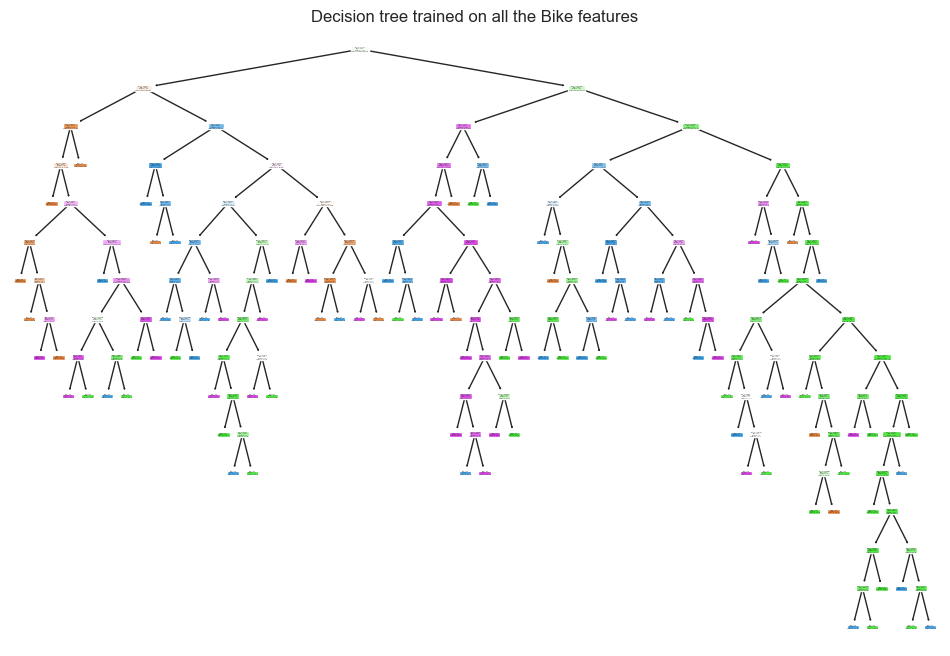

In [371]:
from sklearn.tree import plot_tree

plt.figure(figsize=(12, 8))
plot_tree(rf.estimators_[0], filled=True)
plt.title("Decision tree trained on all the Bike features")
plt.show()

In [372]:
import emlearn
import shutil

cmodel_rf = emlearn.convert(rf, method='loadable')

cmodel_rf.save(file='./random_forest_model.h', name='random_forest_model')

shutil.copyfile('./random_forest_model.h', '.\Implementation\Implementation\src/random_forest_model.h')



'.\\Implementation\\Implementation\\src/random_forest_model.h'

In [373]:
from sklearn.metrics import f1_score

pred_py_rf = rf.predict(X_test)
pred_c_rf = cmodel_rf.predict(X_test)

activitys = ['Break', 'Left', 'Right', 'Straight']

temp = []

for i in pred_c_rf:
    temp.append(activitys[i])

pred_c_rf = temp

val_score_rf = f1_score(y_test, pred_py_rf, average='weighted')
c_val_score_rf = f1_score(y_test, pred_c_rf, average='weighted')

print(f"Python model F1 score: {val_score_rf}")
print(f"C model F1 score: {c_val_score_rf}")


Python model F1 score: 0.9389483746517586
C model F1 score: 0.9389483746517586


In [374]:
print(pred_c_rf[50])
print(X_test[50:51].astype(np.int16))

Break
    xa_mean  ya_mean  zg_mean  xg_max  za_IQR  sma_gyro
50     4681     6440     4660       0    1219     10412


In [375]:
# cmodel_knn = emlearn.convert(knn,  method='loadable')

In [376]:

# pred_py_knn = knn.predict(X_test)
# pred_c_knn = cmodel_knn.predict(X_test)

# activitys = ['Break', 'Left', 'Right', 'Straight']

# temp = []

# for i in pred_c_knn:
#     temp.append(activitys[i])

# pred_c_knn = temp


In [377]:

# val_score_knn = f1_score(y_test, pred_py_knn, average='weighted')
# c_val_score_knn = f1_score(y_test, pred_c_knn, average='weighted')

# print(f"Python model F1 score: {val_score_knn}")
# print(f"C model F1 score: {c_val_score_knn}")